In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np

In [2]:
#get a time vector
Ey = 5 #volts/m
B = 1 #tesla
m = 1e-30 #kg
q = 1e-19 #coulombs
omeg = q*B/m #rad/s

In [3]:
l=np.arange(-2,2,1)
tl = l*np.pi/omeg
t = np.arange(2*np.min(tl),3*np.max(tl),np.max(tl)/1000)
A=np.abs(Ey/B)

x = -(A/omeg)*np.cos(omeg*t) + (Ey/B)*t
y = (A/omeg)*np.sin(omeg*t)
print(x)

[-6.78318531e-10 -6.78161204e-10 -6.78003384e-10 ...  5.20923752e-10
  5.21081572e-10  5.21238898e-10]


In [5]:
ymin=-Ey/(B*omeg)
xmin=(Ey/(B*omeg))*(3/2)*np.pi

x_low = np.arange(xmin,1.3*xmin,(Ey/(B*omeg))/100)

y_low = ymin + (Ey/(2*B*omeg))*(((6*B*omeg)/(Ey))*(x_low-xmin))**(2/3)

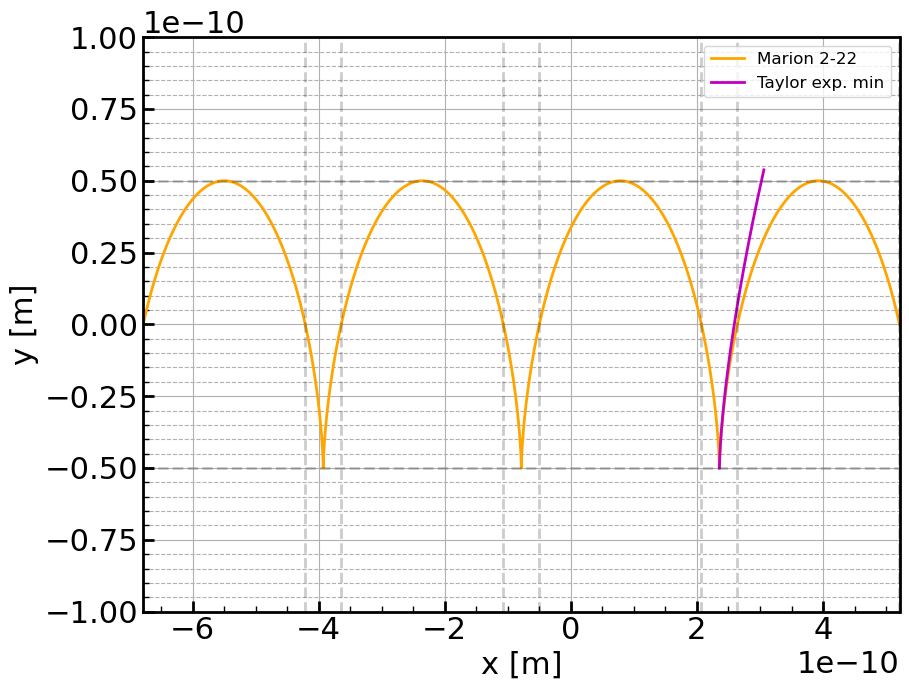

In [6]:
#set up a 1d plot
fig,axes = plt.subplots(1,1,figsize=(9.0,7.0),sharex=True)
ax1 = axes

xunit = (Ey/(B*omeg))
xzero_pos = -xunit + xunit*np.pi*(2*l)
xzero_neg = +xunit + xunit*np.pi*(2*l+1)
xmax = np.max(xzero_neg)
xmin = np.min(xzero_pos)

yint = Ey/omeg
ymax = 2*Ey/omeg


ax1.plot(x,y,color='orange',linestyle="-",linewidth=2, \
         label='Marion 2-22')
ax1.plot(x_low,y_low,color='m',linestyle="-",linewidth=2, \
         label='Taylor exp. min')

alpha=0.2

for xzero in xzero_pos:
  plt.axvline(x=xzero,color='k',linestyle="--",alpha=alpha)
    
for xzero in xzero_neg:
  plt.axvline(x=xzero,color='k',linestyle="--",alpha=alpha)


plt.axhline(y=yint,color='k',linestyle="--",alpha=alpha)
plt.axhline(y=-yint,color='k',linestyle="--",alpha=alpha)

ax1.set_yscale('linear')
#ax1.set_yscale('log')
ax1.set_xlim(xmin, xmax) 
ax1.set_ylim(-ymax,ymax)
ax1.set_xlabel(r'x [m]')
ax1.set_ylabel('y [m]')
ax1.grid(True)
ax1.yaxis.grid(True,which='minor',linestyle='--')
ax1.legend(loc=1,prop={'size':12})
#ax1.legend(bbox_to_anchor=(1.04,1),borderaxespad=0,prop={'size':22})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
#plt.savefig('figures/figure.png')
plt.show()